# 19. KAIST Multi-Sensor Pipeline Example

This notebook mirrors the KAIST data import and ground-truth frame handling from notebook 18, then rebuilds the rolling calibration example with the new `multi_sensor_pipeline` package.

The structure is intentionally modular: definitions, imports, data preparation, stream construction, measurement plotting, graph solving, and result plotting are kept in separate cells so each ownership boundary is visible.


## 1. Definitions

Only plain Python values live here. Imports and conversion to `Path`/`numpy` objects happen in the next cells, keeping configuration easy to copy into other notebooks.


In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd()
for candidate in (ROOT, *ROOT.parents):
    if (candidate / 'src' / 'multi_sensor_pipeline').exists():
        ROOT = candidate
        break
if str(ROOT / 'src') not in sys.path:
    sys.path.insert(0, str(ROOT / 'src'))

OUTPUT_SUBDIR = 'notebook19_kaist_pipeline'
OUT = ROOT / 'outputs' / OUTPUT_SUBDIR
OUT.mkdir(parents=True, exist_ok=True)

import matplotlib.pyplot as plt
import mrob
import numpy as np
import pandas as pd
from IPython.display import display

import data_processing
import transform
from tools_ahrs import plot
from kaist_dataset import load_imus
from kaist_dataset.data import import_true_trajectory
from kaist_dataset.lidar import load_lidar_data_csv
from kaist_dataset.lidar_map import load_lidar_map_pose_csv
from calib_observability.backend import estimate_poses_dummy
from calib_observability.simulation import reframe_dataset_to_fixed_extrinsic
from calib_observability.workflows import build_dataset_from_imported_sensor_streams

from multi_sensor_pipeline import (
    ComplexAccelStream,
    GyroStream,
    LidarOdometryStream,
    LidarPoseStream,
    RollingGraph,
    Sensor,
    SimpleAccelStream,
    SolverConfig,
    TrajectoryConfig,
    VariableConfig,
    VariableKey,
    VariableType,
    plot_calibration_estimates,
    plot_rolling_trajectory,
    plot_stream_measurements,
    print_rolling_result_summary,
)

In [2]:
# Dataset and output controls copied from notebook 15.
DATASET_ROOT_TEXT = '/mnt/d/Downloads/MobRobLab/KAISTDataset/Urban16'
LIDAR_ODOMETRY_CSV_TEXT_LEFT = '~/Skoltech/phd_proposal/data/KAISTDataset/Urban16/lidar_odometry_vlp_left.csv'
LIDAR_ODOMETRY_CSV_TEXT_RIGHT = '~/Skoltech/phd_proposal/data/KAISTDataset/Urban16/lidar_odometry_vlp_right.csv'
LIDAR_ODOMETRY_CSV_TEXT = LIDAR_ODOMETRY_CSV_TEXT_LEFT
LIDAR_MAP_POSE_CSV_TEXT_LEFT = 'data/KAISTDataset/Urban16/lidar_map_poses_vlp_left.csv'
LIDAR_MAP_POSE_CSV_TEXT_RIGHT = 'data/KAISTDataset/Urban16/lidar_map_poses_vlp_right.csv'
SAVE_FIGURES = True

# Real sensor import controls.
TARGET_IMU_FREQUENCY_HZ = 100.0
MAX_IMU_FILES = None
LIDAR_SCAN_PERIOD_S = None
INVERT_IMPORTED_LIDAR_MEASUREMENTS = False
FIXED_EXTRINSIC = 'T_B_L'

# Initial-guess controls. These are estimator guesses, not ground truth.
T_B_I_ESTIMATE_INITIAL_LIST = [
    [1.0, 0.0, 0.0, 0.0],
    [0.0, 1.0, 0.0, 0.0],
    [0.0, 0.0, 1.0, 0.0],
    [0.0, 0.0, 0.0, 1.0],
]
T_B_L_ESTIMATE_INITIAL_LIST = [
    [1.0, 0.0, 0.0, 0.0],
    [0.0, 1.0, 0.0, 0.0],
    [0.0, 0.0, 1.0, 0.0],
    [0.0, 0.0, 0.0, 1.0],
]
BIAS_ESTIMATE_INITIAL_LIST = [0.0, 0.0, 0.0]
TAU_I_ESTIMATE_INITIAL = 2.0
TAU_L_ESTIMATE_INITIAL = 0.0

# Rolling factor-graph controls. Notebook 15 used WINDOW_SIZE * 10 and half-window steps.
WINDOW_SIZE = 5.0
STEP_SIZE = 1.0
ROLLING_WINDOW_SIZE = WINDOW_SIZE * 10.0
ROLLING_STEP_SIZE = ROLLING_WINDOW_SIZE / 2.0
IMU_SAMPLES_PER_FACTOR = None
LIDAR_SAMPLES_PER_FACTOR = None
USE_LIDAR_RELATIVE_ODOMETRY_FACTORS = False
USE_LIDAR_MAP_POSE_FACTORS = True
LIDAR_MAP_POSE_FACTOR_STRIDE = 1
FACTOR_GRAPH_METHOD = 'LM'
ACC_MODE = 'simple'
IMU_TIME_OFFSET_MARGIN = 2.5 * 2.0
LIDAR_TIME_OFFSET_MARGIN = 2.5 * 2.0

# Imported-data noise/linearization assumptions.
STATIONARY_SAMPLES = 1000
GYRO_NOISE_FLOOR = 1e-6
ACCEL_NOISE_FLOOR = 1e-6
LIDAR_INFORMATION_SCALE = 1e-2
LIDAR_INFORMATION = np.diag([
    1e-2,
    1e-2,
    1e-2,
    1.0,
    1.0,
    1.0,
])
LIDAR_MAP_POSE_INFORMATION = np.diag([
    1e-2,
    1e-2,
    1e-2,
    1.0,
    1.0,
    1.0,
])

# Solver and prior settings copied in spirit from notebook 15.
# IMU_PRIOR_SOURCE controls only the soft prior target. With 'optimized',
# the first window falls back to the configured prior_value and later windows
# use the previous rolling-window solution as the prior target.
SOLVER_SCHEDULER = [(1e-5, 100), (1e-5, 100), (1e-9, 100)]
GRAVITY_WORLD_LIST = [0.0, 0.0, 9.81]
T_B_I_PRIOR_INFORMATION_DIAG = [1e1, 1e1, 1e1, 1e3, 1e3, 1e3]
TAU_I_PRIOR_INFORMATION = 1e2
BIAS_PRIOR_INFORMATION = 1e5
GYRO_INFORMATION = 1e0
ACCEL_INFORMATION = 1e0
IMU_PRIOR_SOURCE = 'optimized'  # alternatives supported by VariableConfig: 'constant', 'numerical', 'default'


## 2. Imports

The old modules are imported for dataset loading, frame conversion, and trajectory initialization. The new pipeline imports are grouped separately.


In [3]:


DATASET_ROOT = Path(DATASET_ROOT_TEXT)
LIDAR_ODOMETRY_CSV_LEFT = Path(LIDAR_ODOMETRY_CSV_TEXT_LEFT).expanduser()
LIDAR_ODOMETRY_CSV_RIGHT = Path(LIDAR_ODOMETRY_CSV_TEXT_RIGHT).expanduser()
LIDAR_ODOMETRY_CSV = Path(LIDAR_ODOMETRY_CSV_TEXT).expanduser()
LIDAR_MAP_POSE_CSV_LEFT = (ROOT / Path(LIDAR_MAP_POSE_CSV_TEXT_LEFT)).expanduser()
LIDAR_MAP_POSE_CSV_RIGHT = (ROOT / Path(LIDAR_MAP_POSE_CSV_TEXT_RIGHT)).expanduser()
T_B_I_ESTIMATE_INITIAL = np.asarray(T_B_I_ESTIMATE_INITIAL_LIST, dtype=float)
T_B_L_ESTIMATE_INITIAL = np.asarray(T_B_L_ESTIMATE_INITIAL_LIST, dtype=float)
BIAS_ESTIMATE_INITIAL = np.asarray(BIAS_ESTIMATE_INITIAL_LIST, dtype=float)
GRAVITY_WORLD = np.asarray(GRAVITY_WORLD_LIST, dtype=float)


## 3. Helper Definitions

These small helpers are copied from the notebook 15 workflow where they are specific to the New College imported data layout.


In [4]:
def lidar_scan_timestamps_for_pipeline(lidar_data):
    if lidar_data.scan_timestamps_s is not None:
        return np.asarray(lidar_data.scan_timestamps_s, dtype=float)
    midpoint_times = np.asarray(lidar_data.timestamps_s, dtype=float)
    if midpoint_times.size == 0:
        raise ValueError('LiDAR data has no timestamps')
    if midpoint_times.size == 1:
        if LIDAR_SCAN_PERIOD_S is None:
            raise ValueError('Set LIDAR_SCAN_PERIOD_S when only one LiDAR midpoint timestamp is available')
        half_period = 0.5 * float(LIDAR_SCAN_PERIOD_S)
        return np.array([midpoint_times[0] - half_period, midpoint_times[0] + half_period], dtype=float)
    boundaries = np.empty(midpoint_times.size + 1, dtype=float)
    boundaries[1:-1] = 0.5 * (midpoint_times[:-1] + midpoint_times[1:])
    boundaries[0] = midpoint_times[0] - (boundaries[1] - midpoint_times[0])
    boundaries[-1] = midpoint_times[-1] + (midpoint_times[-1] - boundaries[-2])
    return boundaries


def accumulate_lidar_poses(relative_poses):
    poses = np.empty((len(relative_poses) + 1, 4, 4), dtype=float)
    poses[0] = np.eye(4)
    for measurement_index, relative_pose in enumerate(relative_poses):
        poses[measurement_index + 1] = poses[measurement_index] @ relative_pose
    return poses


def result_table(results):
    rows = []
    for result in results:
        row = {
            'window': result.window_index,
            'start': result.window_start,
            'end': result.window_end,
            'chi2_before': result.chi2_before,
            'chi2_after': result.chi2_after,
            'factors': sum(result.factor_counts.values()),
        }
        for key, value in result.calibration_values.items():
            if key.variable_type == VariableType.TIME_OFFSET:
                row[key.label] = float(value)
        rows.append(row)
    return pd.DataFrame(rows)


## 4. New College Data Import

This section follows notebook 15: load the real Realsense IMU, load the precomputed LiDAR odometry CSV, estimate simple noise proxies, and build the imported dataset object used for consistent frames and references.


In [5]:
imu_streams_raw = load_imus(
    DATASET_ROOT / 'urban16_data' / 'urban16' / "sensor_data",
    target_frequency_hz=TARGET_IMU_FREQUENCY_HZ,
    max_files=MAX_IMU_FILES,
)
primary_imu_name = list(imu_streams_raw.keys())[0]
primary_imu = imu_streams_raw[primary_imu_name]

lidar_data = load_lidar_data_csv(LIDAR_ODOMETRY_CSV)
lidar_right_data = load_lidar_data_csv(LIDAR_ODOMETRY_CSV_RIGHT)
velocity_timestamps = lidar_data.scan_timestamps_s if lidar_data.scan_timestamps_s is not None else lidar_data.timestamps_s
lidar_angvel_radps = transform.relative_se3_to_angvels(lidar_data.relative_poses_se3, velocity_timestamps)
lidar_velocity_mps = transform.relative_se3_to_velocities(lidar_data.relative_poses_se3, velocity_timestamps)
lidar_noise = np.hstack((
    np.std(lidar_angvel_radps[:STATIONARY_SAMPLES], axis=0),
    np.std(lidar_velocity_mps[:STATIONARY_SAMPLES], axis=0),
))
lidar_noise = np.maximum(lidar_noise, 1e-6)

print('Primary IMU:', primary_imu_name, primary_imu.timestamps_s.shape)
print('LiDAR relative poses:', lidar_data.relative_poses_se3.shape)
print('LiDAR noise proxy:', lidar_noise)


/home/camel/Skoltech/phd_proposal/src/kaist_dataset/lidar.py:752: DtypeWarning: Columns (22) have mixed types. Specify dtype option on import or set low_memory=False.
  table = pd.read_csv(source_path)
/home/camel/Skoltech/phd_proposal/src/kaist_dataset/lidar.py:752: DtypeWarning: Columns (22) have mixed types. Specify dtype option on import or set low_memory=False.
  table = pd.read_csv(source_path)


Primary IMU: sensor_data_xsens_imu (449195,)
LiDAR relative poses: (44534, 4, 4)
LiDAR noise proxy: [0.02353761 0.04107867 0.03957999 2.09791309 2.82371835 1.96214716]


## 5. Dataset Frames And Properly Rotated Ground Truth

The body/LiDAR/Realsense transforms and ground-truth rotation are copied from notebook 15. The final `true_poses` trajectory is expressed in the LiDAR-world convention used by the LiDAR odometry pipeline.


In [6]:
##################################################
# KAIST LiDAR extrinsics
##################################################

# Vehicle2LeftVLP.txt:
# pose of the Left VLP-16 in the vehicle/body frame.
#
# Convention:
# T_A_B maps coordinates from frame B to frame A.
#
# Therefore:
# T_B_LL : Left-LiDAR -> Body
# T_LL_B : Body -> Left-LiDAR

T_B_LL_INITIAL = np.array([
    [-0.514066, -0.702201, -0.492595, -0.440699],
    [ 0.486485, -0.711672,  0.506809,  0.397052],
    [-0.706447,  0.0208933,  0.707457,  1.90953],
    [ 0.0,       0.0,        0.0,       1.0],
], dtype=float)

T_LL_B_INITIAL = np.linalg.inv(T_B_LL_INITIAL)

T_B_RL_INITIAL = np.array([
    [-0.512152,  0.699241, -0.498761, -0.449885],
    [-0.494811, -0.714859, -0.494104, -0.416713],
    [-0.702041, -0.0062642, 0.712109,  1.91294],
    [ 0.0,       0.0,       0.0,       1.0],
], dtype=float)

T_RL_B_INITIAL = np.linalg.inv(T_B_RL_INITIAL)

T_B_LL_INITIAL_TANGENT = mrob.SE3(T_B_LL_INITIAL).Ln()
T_B_RL_INITIAL_TANGENT = mrob.SE3(T_B_RL_INITIAL).Ln()

T_I_B_INITIAL = np.array([[1, 0, 0, -0.07], [0, 1, 0, 0], [0, 0, 1, 1.7], [0, 0, 0, 1]])
T_B_I_INITIAL_FOR_DATASET = np.linalg.inv(T_I_B_INITIAL)
T_B_I_INITIAL_TANGENT = mrob.SE3(T_B_I_INITIAL_FOR_DATASET).Ln()

GYRO_BIAS_INITIAL_FOR_DATASET = np.zeros(3, dtype=float)
TAU_I_WEBSITE_REFERENCE = 0.056010849
TAU_I_NUMERICAL_REFERENCE = 0.11101
TAU_I_INITIAL_FOR_DATASET = 0
TAU_L_INITIAL_FOR_DATASET = 0.0

if lidar_data.scan_timestamps_s is not None and len(lidar_data.scan_timestamps_s) > 1:
    LIDAR_RATE_HZ = 1.0 / float(np.median(np.diff(lidar_data.scan_timestamps_s)))
elif len(lidar_data.timestamps_s) > 1:
    LIDAR_RATE_HZ = 1.0 / float(np.median(np.diff(lidar_data.timestamps_s)))
elif LIDAR_SCAN_PERIOD_S is not None:
    LIDAR_RATE_HZ = 1.0 / float(LIDAR_SCAN_PERIOD_S)
else:
    LIDAR_RATE_HZ = 5.0

IMPORTED_GYRO_NOISE_STD_RADPS = max(float(np.max(np.std(primary_imu.gyro_radps[:STATIONARY_SAMPLES], axis=0))), GYRO_NOISE_FLOOR)
IMPORTED_ACCEL_NOISE_STD_MPS2 = max(float(np.max(np.std(primary_imu.accel_mps2[:STATIONARY_SAMPLES], axis=0))), ACCEL_NOISE_FLOOR)
IMPORTED_LIDAR_POSE_NOISE_STD = lidar_noise

lidar_scan_timestamps_s = lidar_scan_timestamps_for_pipeline(lidar_data)
raw_dataset_left = build_dataset_from_imported_sensor_streams(
    imu_timestamps=primary_imu.timestamps_s,
    gyroscope=primary_imu.gyro_radps,
    accelerometer=primary_imu.accel_mps2,
    lidar_scan_timestamps=lidar_scan_timestamps_s,
    lidar_relative_poses=lidar_data.relative_poses_se3,
    T_B_I_initial_tangent=T_B_I_INITIAL_TANGENT,
    T_B_L_initial_tangent=T_B_LL_INITIAL_TANGENT,
    gyro_bias_initial=GYRO_BIAS_INITIAL_FOR_DATASET,
    tau_I_initial=TAU_I_INITIAL_FOR_DATASET,
    tau_L_initial=TAU_L_INITIAL_FOR_DATASET,
    gyro_noise_std=IMPORTED_GYRO_NOISE_STD_RADPS,
    accel_noise_std=IMPORTED_ACCEL_NOISE_STD_MPS2,
    lidar_pose_noise_std=IMPORTED_LIDAR_POSE_NOISE_STD,
    invert_lidar_measurements=INVERT_IMPORTED_LIDAR_MEASUREMENTS,
    true_poses_path=DATASET_ROOT / 'urban16_pose/urban16/global_pose.csv',
    poses_import_function = import_true_trajectory,
)
dataset = raw_dataset_left
# dataset = reframe_dataset_to_fixed_extrinsic(raw_dataset_left, FIXED_EXTRINSIC)
pose_provider = estimate_poses_dummy(dataset)

T_B_GPS_INITIAL = np.array([
    [ 1.,  0.,  0., 0.],
    [0.,  1,  0., 0.],
    [ 0., 0.,  1., 1.93],
    [ 0.,  0.,  0., 1.],
])
T_B_L_WORLD = T_B_LL_INITIAL
true_timestamps, true_trajectory = import_true_trajectory(DATASET_ROOT / 'urban16_pose/urban16/global_pose.csv')
# true_trajectory = transform.transform_se3s(true_trajectory, np.linalg.inv(T_B_L_WORLD))
# true_trajectory = transform.transform_se3s(true_trajectory, T_B_L_WORLD, left=False)
true_poses = true_trajectory
pose_timestamps = true_timestamps

original_imu_timestamps = dataset.imu.sensor_timestamps.copy()
original_gyrs = dataset.imu.gyroscope.copy()
original_accs = dataset.imu.accelerometer.copy()

##################################################
# LiDAR odometry in LiDAR and body coordinates
##################################################

lidar_timestamps = np.asarray(
    dataset.lidar.sensor_timestamps,
    dtype=float,
)
lidar_right_timestamps = lidar_right_data.scan_timestamps_s

# Raw ICP relative measurements.
#
# Each element is a relative motion expressed in the Left-LiDAR frame.
lidar_relative_poses = np.asarray(
    dataset.lidar.measurements,
    dtype=float,
)

if len(lidar_timestamps) != len(lidar_relative_poses) + 1:
    raise ValueError(
        "Expected one more LiDAR scan timestamp than relative pose measurements"
    )

##################################################
# Convert each LiDAR relative increment into body coordinates
##################################################

# dT_B = T_B_L @ dT_L @ T_L_B
lidar_relative_poses_body = (
    T_B_LL_INITIAL
    @ lidar_relative_poses
    @ T_LL_B_INITIAL
)
lidar_right_relative_poses = lidar_right_data.relative_poses_se3

##################################################
# Accumulate odometry in its native LiDAR frame
##################################################

# T_L0_Lk
lidar_poses = accumulate_lidar_poses(lidar_relative_poses)
lidar_right_poses = accumulate_lidar_poses(lidar_right_relative_poses)

##################################################
# Accumulate the same motion in body coordinates
##################################################

# T_B0_Bk
lidar_poses_body = accumulate_lidar_poses(
    lidar_relative_poses_body
)

T_B_I_REFERENCE = dataset.T_B_I_true.copy()
TAU_I_REFERENCE = float(dataset.tau_I_true)
BIAS_REFERENCE = dataset.gyro_bias_true.copy()
T_B_L_REFERENCE = dataset.T_B_L_true.copy()
TAU_L_REFERENCE = float(dataset.tau_L_true)

print({
    'dataset_start': dataset.start_time,
    'dataset_end': dataset.end_time,
    'imu_samples': len(dataset.imu.sensor_timestamps),
    'lidar_measurements': len(dataset.lidar.measurements),
    'fixed_extrinsic': FIXED_EXTRINSIC,
    'lidar_rate_hz_estimate': LIDAR_RATE_HZ,
})
print('reference tau_I:', TAU_I_REFERENCE)
print('reference T_B_I Ln:', mrob.SE3(T_B_I_REFERENCE).Ln())


{'dataset_start': 1524205131.6004922, 'dataset_end': 1524209584.84052, 'imu_samples': 449178, 'lidar_measurements': 44534, 'fixed_extrinsic': 'T_B_L', 'lidar_rate_hz_estimate': 9.915026298682111}
reference tau_I: 0.0
reference T_B_I Ln: [-0.    0.   -0.    0.07  0.   -1.7 ]


## Absolute LiDAR Map Pose Observations

Load scan-to-map `T_W_L` CSVs generated by notebook 21 and convert them into body-frame pose observations for `PoseObservationStream`. With `T_A_B` convention, the CSV gives Left/Right LiDAR poses in the world frame, so the body observations are `T_W_B = T_W_L @ T_L_B` for the left sensor and `T_W_B = T_W_R @ T_R_B` for the right sensor.

In [ ]:
##################################################
# Absolute Left/Right LiDAR scan-to-map pose observations
##################################################

# Notebook 21 writes T_W_L, mapping LiDAR-frame points into the LAS/map/world frame.
# PoseObservationStream observes trajectory pose nodes directly, so convert to body poses:
#
#   T_W_B_left  = T_W_LL @ T_LL_B
#   T_W_B_right = T_W_RL @ T_RL_B
#
# where T_LL_B and T_RL_B are the inverse KAIST LiDAR-to-body extrinsics.

csv_path_to_verify = LIDAR_MAP_POSE_CSV_LEFT
csv_timestamps_s, csv_poses_T_W_L, csv_dataframe = load_lidar_map_pose_csv(csv_path_to_verify)
lidar_pose_left_success = csv_dataframe['success'].to_numpy(dtype=bool) if 'success' in csv_dataframe else np.ones(len(csv_dataframe), dtype=bool)
lidar_pose_left_finite = np.all(np.isfinite(csv_poses_T_W_L[:, :3, :]), axis=(1, 2))
lidar_pose_left_mask = lidar_pose_left_success & lidar_pose_left_finite
lidar_pose_timestamps_left = csv_timestamps_s[lidar_pose_left_mask]
lidar_sensor_poses_left_T_W_L = csv_poses_T_W_L[lidar_pose_left_mask]
lidar_poses_left = lidar_sensor_poses_left_T_W_L @ T_LL_B_INITIAL
lidar_map_pose_dataframe_left = csv_dataframe.loc[lidar_pose_left_mask].reset_index(drop=True)

if LIDAR_MAP_POSE_CSV_RIGHT.is_file():
    csv_path_to_verify = LIDAR_MAP_POSE_CSV_RIGHT
    csv_timestamps_s, csv_poses_T_W_L, csv_dataframe = load_lidar_map_pose_csv(csv_path_to_verify)
    csv_poses_T_W_RL = csv_poses_T_W_L
    lidar_pose_right_success = csv_dataframe['success'].to_numpy(dtype=bool) if 'success' in csv_dataframe else np.ones(len(csv_dataframe), dtype=bool)
    lidar_pose_right_finite = np.all(np.isfinite(csv_poses_T_W_RL[:, :3, :]), axis=(1, 2))
    lidar_pose_right_mask = lidar_pose_right_success & lidar_pose_right_finite
    lidar_pose_timestamps_right = csv_timestamps_s[lidar_pose_right_mask]
    lidar_sensor_poses_right_T_W_L = csv_poses_T_W_RL[lidar_pose_right_mask]
    lidar_poses_right = lidar_sensor_poses_right_T_W_L @ T_RL_B_INITIAL
    lidar_map_pose_dataframe_right = csv_dataframe.loc[lidar_pose_right_mask].reset_index(drop=True)
else:
    warnings.warn(f'Right LiDAR map pose CSV not found: {LIDAR_MAP_POSE_CSV_RIGHT}. Right absolute pose stream will be skipped.', RuntimeWarning)
    lidar_pose_timestamps_right = np.empty(0, dtype=float)
    lidar_sensor_poses_right_T_W_L = np.empty((0, 4, 4), dtype=float)
    lidar_poses_right = np.empty((0, 4, 4), dtype=float)
    lidar_map_pose_dataframe_right = pd.DataFrame()

if len(lidar_poses_left) == 0:
    raise ValueError('Left LiDAR map pose CSV has no successful finite T_W_L rows.')

print('Left LiDAR map pose CSV:', LIDAR_MAP_POSE_CSV_LEFT)
print('  usable poses:', len(lidar_poses_left), '/', len(lidar_pose_left_mask))
print('  timestamp range:', lidar_pose_timestamps_left[0], '...', lidar_pose_timestamps_left[-1])
print('Right LiDAR map pose CSV:', LIDAR_MAP_POSE_CSV_RIGHT)
print('  usable poses:', len(lidar_poses_right))
if len(lidar_poses_right):
    print('  timestamp range:', lidar_pose_timestamps_right[0], '...', lidar_pose_timestamps_right[-1])

In [7]:
##################################################
# Restrict LiDAR odometry to the reference trajectory time support
##################################################

overlap_start = max(
    lidar_timestamps[0],
    true_timestamps[0],
)

overlap_end = min(
    lidar_timestamps[-1],
    true_timestamps[-1],
)

lidar_start_index = np.searchsorted(
    lidar_timestamps,
    overlap_start,
    side='left',
)

lidar_end_index = np.searchsorted(
    lidar_timestamps,
    overlap_end,
    side='right',
)

lidar_timestamps_world = lidar_timestamps[
    lidar_start_index:lidar_end_index
]

##################################################
# Rebase accumulated LiDAR odometry at the first overlapping scan
##################################################

# lidar_poses contains T_L0_Lk.
# Convert it to T_Lstart_Lk so the first pose of the plotted trajectory is I.
T_L0_Lstart = lidar_poses[lidar_start_index]

lidar_poses_overlap = (
    np.linalg.inv(T_L0_Lstart)
    @ lidar_poses[lidar_start_index:lidar_end_index]
)

##################################################
# Express the relative LiDAR trajectory as body motion
##################################################

lidar_poses_body_overlap = (
    T_B_LL_INITIAL
    @ lidar_poses_overlap
    @ T_LL_B_INITIAL
)

##################################################
# Anchor the first overlapping body pose in the KAIST world
##################################################

first_true_index = np.argmin(
    np.abs(
        true_timestamps
        - lidar_timestamps_world[0]
    )
)

T_W_B_start = true_poses[first_true_index]

lidar_poses_world = (
    T_W_B_start
    @ lidar_poses_body_overlap
)

print(
    'LiDAR / reference anchor time difference:',
    true_timestamps[first_true_index]
    - lidar_timestamps_world[0],
)

LiDAR / reference anchor time difference: 0.001613616943359375


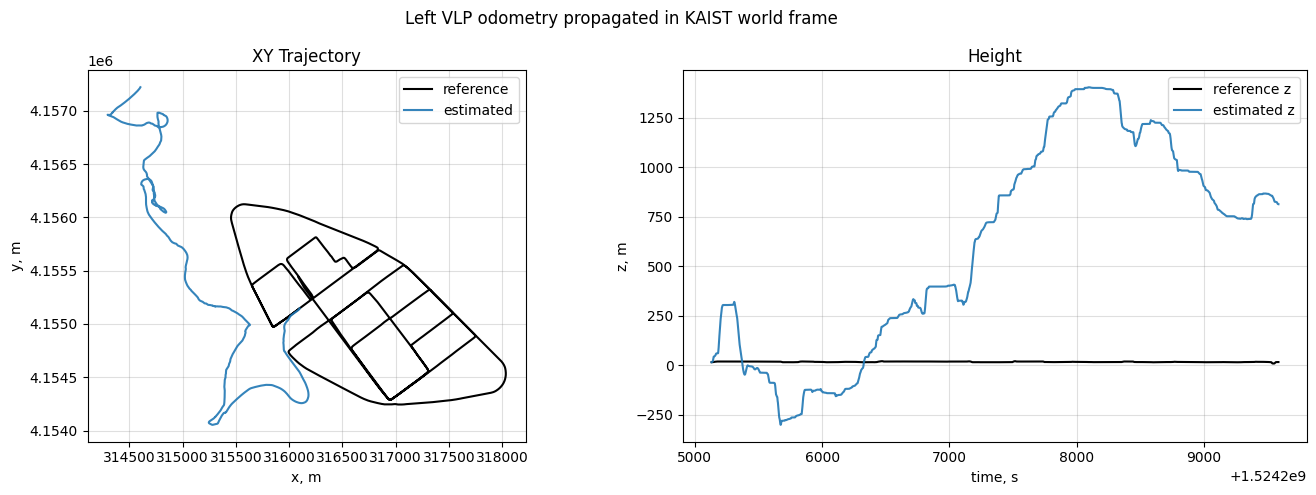

In [8]:
reference_mask = (
    (true_timestamps >= lidar_timestamps_world[0])
    & (true_timestamps <= lidar_timestamps_world[-1])
)

fig, axes = plot_rolling_trajectory(
    lidar_timestamps_world,
    lidar_poses_world,
    reference_timestamps=true_timestamps[reference_mask],
    reference_poses=true_poses[reference_mask],
    title='Left VLP odometry propagated in KAIST world frame',
)

plt.show()

maximum GT timestamp mismatch [s]: 39.8901150226593
gravity-like samples: 392411 / 445321

g_W = [0, 0, +9.81]
  RMSE xyz [m/s^2]: [0.72158755 0.63358964 0.30347131]
  total RMSE [m/s^2]: 1.0070845338970564
  mean cosine: 0.9952208723565167

g_W = [0, 0, -9.81]
  RMSE xyz [m/s^2]: [ 0.76356949  0.7841543  19.6060506 ]
  total RMSE [m/s^2]: 19.636577004319694
  mean cosine: -0.9952208723565167

Winning gravity direction: +Z


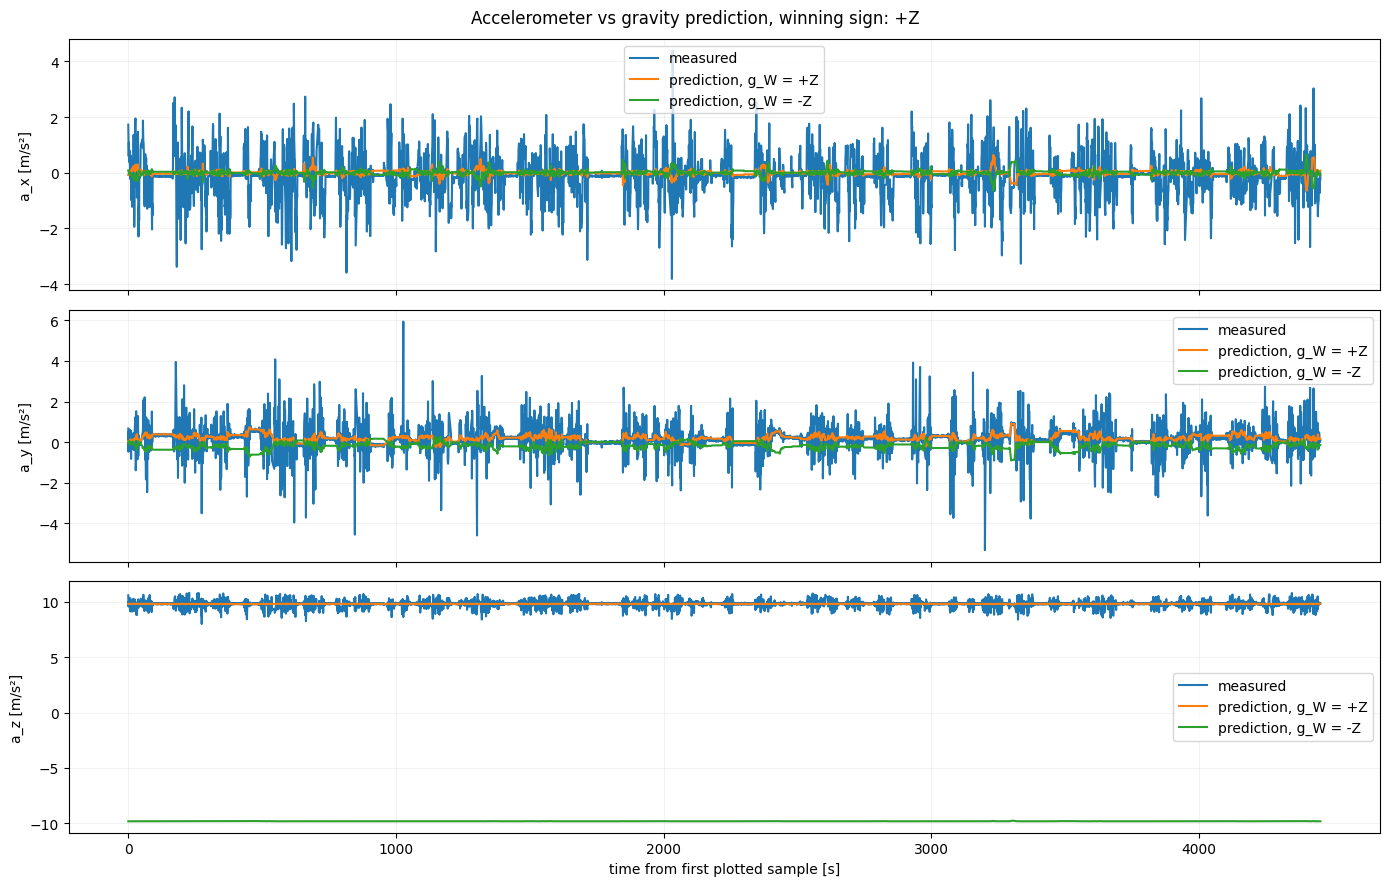

In [9]:
##################################################
# Check the world-gravity sign against the real accelerometer
##################################################

TAU_I_GRAVITY_CHECK = 0.0
GRAVITY_MAGNITUDE = 9.81

imu_timestamps_check = np.asarray(original_imu_timestamps, dtype=float)
imu_accs_check = np.asarray(original_accs, dtype=float)
imu_gyrs_check = np.asarray(original_gyrs, dtype=float)

##################################################
# A sensor sample at time s corresponds to trajectory time
# t = s - tau under the convention used by the factor:
#
#     sensor_query_time = pose_time + tau
##################################################

pose_query_timestamps = imu_timestamps_check - TAU_I_GRAVITY_CHECK

valid_mask = ((pose_query_timestamps >= true_timestamps[0]) & (pose_query_timestamps <= true_timestamps[-1]))

pose_query_timestamps = pose_query_timestamps[valid_mask]
measured_accs = imu_accs_check[valid_mask]
measured_gyrs = imu_gyrs_check[valid_mask]

##################################################
# Match each IMU measurement to the nearest ground-truth pose
##################################################

right_indices = np.searchsorted(true_timestamps, pose_query_timestamps, side="left",)

right_indices = np.clip(right_indices, 1, len(true_timestamps) - 1,)

left_indices = right_indices - 1

use_right = ( np.abs(true_timestamps[right_indices] - pose_query_timestamps) < np.abs(pose_query_timestamps - true_timestamps[left_indices]))

pose_indices = np.where(use_right, right_indices, left_indices,)

matched_pose_timestamps = true_timestamps[pose_indices]
R_W_B = true_poses[pose_indices, :3, :3]

print("maximum GT timestamp mismatch [s]:", np.max(np.abs(matched_pose_timestamps - pose_query_timestamps)),)

##################################################
# Reproduce the SimpleAccel factor prediction
##################################################

C_B_I = T_B_I_INITIAL_FOR_DATASET[:3, :3]

def predicted_specific_force(gravity_world):
    gravity_world = np.asarray(gravity_world, dtype=float)

    gravity_body = np.einsum(
        "nij,j->ni",
        np.transpose(R_W_B, (0, 2, 1)),
        gravity_world,
    )

    # Column-vector formula:
    #
    #     f_I = C_B_I.T @ f_B
    #
    # For row-wise vectors this is f_B @ C_B_I.
    return gravity_body @ C_B_I

predicted_accs_positive = predicted_specific_force([0.0, 0.0, GRAVITY_MAGNITUDE])
predicted_accs_negative = predicted_specific_force([0.0, 0.0, -GRAVITY_MAGNITUDE])

##################################################
# Prefer approximately gravity-dominated samples
##################################################

acc_norms = np.linalg.norm(measured_accs, axis=1)
gyro_norms = np.linalg.norm(measured_gyrs, axis=1)

quiet_mask = (
    (np.abs(acc_norms - GRAVITY_MAGNITUDE) < 1.0)
    & (gyro_norms < 0.1)
)

if np.count_nonzero(quiet_mask) < 100:
    print(
        "Only",
        np.count_nonzero(quiet_mask),
        "strict gravity-like samples found; using a looser mask.",
    )

    quiet_mask = (
        (np.abs(acc_norms - GRAVITY_MAGNITUDE) < 2.0)
        & (gyro_norms < 0.2)
    )

print(
    "gravity-like samples:",
    np.count_nonzero(quiet_mask),
    "/",
    len(quiet_mask),
)

##################################################
# Compare both signs quantitatively
##################################################

def gravity_score(predicted):
    measured = measured_accs[quiet_mask]
    predicted = predicted[quiet_mask]

    residuals = predicted - measured

    rmse_xyz = np.sqrt(
        np.mean(
            residuals**2,
            axis=0,
        )
    )

    rmse_total = np.sqrt(
        np.mean(
            np.sum(
                residuals**2,
                axis=1,
            )
        )
    )

    cosine = np.sum(
        measured * predicted,
        axis=1,
    ) / (
        np.linalg.norm(measured, axis=1)
        * np.linalg.norm(predicted, axis=1)
    )

    return rmse_xyz, rmse_total, np.mean(cosine)


positive_rmse_xyz, positive_rmse, positive_cosine = gravity_score(
    predicted_accs_positive
)

negative_rmse_xyz, negative_rmse, negative_cosine = gravity_score(
    predicted_accs_negative
)

print()
print("g_W = [0, 0, +9.81]")
print("  RMSE xyz [m/s^2]:", positive_rmse_xyz)
print("  total RMSE [m/s^2]:", positive_rmse)
print("  mean cosine:", positive_cosine)

print()
print("g_W = [0, 0, -9.81]")
print("  RMSE xyz [m/s^2]:", negative_rmse_xyz)
print("  total RMSE [m/s^2]:", negative_rmse)
print("  mean cosine:", negative_cosine)

if positive_rmse < negative_rmse:
    winning_sign = "+Z"
    winning_prediction = predicted_accs_positive
else:
    winning_sign = "-Z"
    winning_prediction = predicted_accs_negative

print()
print("Winning gravity direction:", winning_sign)

##################################################
# Plot measured and predicted acceleration
##################################################

plot_indices = np.flatnonzero(quiet_mask)

if len(plot_indices) > 5000:
    plot_indices = plot_indices[
        ::max(1, len(plot_indices) // 5000)
    ]

plot_times = pose_query_timestamps[plot_indices]
plot_times = plot_times - plot_times[0]

fig, axes = plt.subplots(
    3,
    1,
    figsize=(14, 9),
    sharex=True,
)

axis_names = ("x", "y", "z")

for axis_index, axis_name in enumerate(axis_names):
    axes[axis_index].plot(
        plot_times,
        measured_accs[plot_indices, axis_index],
        label="measured",
    )

    axes[axis_index].plot(
        plot_times,
        predicted_accs_positive[plot_indices, axis_index],
        label="prediction, g_W = +Z",
    )

    axes[axis_index].plot(
        plot_times,
        predicted_accs_negative[plot_indices, axis_index],
        label="prediction, g_W = -Z",
    )

    axes[axis_index].set_ylabel(
        f"a_{axis_name} [m/s²]"
    )

    axes[axis_index].grid(True)
    axes[axis_index].legend()

axes[-1].set_xlabel("time from first plotted sample [s]")

fig.suptitle(
    f"Accelerometer vs gravity prediction, winning sign: {winning_sign}"
)

fig.tight_layout()
plt.show()

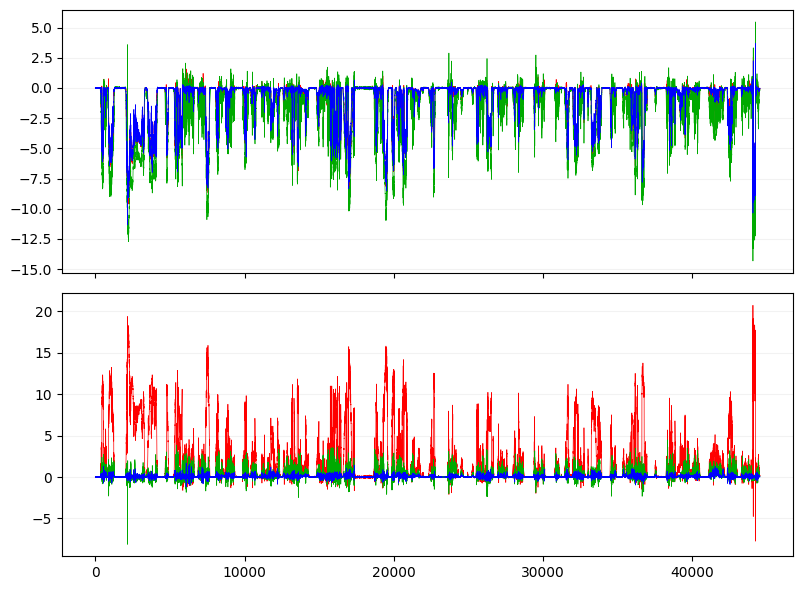

In [10]:
##################################################
# Inspect LiDAR-relative velocity in sensor/body coordinates
##################################################

lidar_velocities_lidar = transform.relative_se3_to_velocities(
    lidar_relative_poses,
    lidar_timestamps,
)

lidar_velocities_body = transform.relative_se3_to_velocities(
    lidar_relative_poses_body,
    lidar_timestamps,
)

plot(
    lidar_velocities_lidar,
    lidar_velocities_body,
)

In [11]:
from scipy.spatial.transform import Rotation

##################################################
# Diagnose systematic bias in pairwise LiDAR odometry
##################################################

translations_body = lidar_relative_poses_body[:, :3, 3]

rotation_vectors_body = Rotation.from_matrix(
    lidar_relative_poses_body[:, :3, :3]
).as_rotvec()

print(
    'mean translation per scan [m]:',
    np.mean(translations_body, axis=0),
)

print(
    'translation RMS per scan [m]:',
    np.sqrt(
        np.mean(
            translations_body**2,
            axis=0,
        )
    ),
)

print(
    'mean rotation per scan [deg]:',
    np.rad2deg(
        np.mean(
            rotation_vectors_body,
            axis=0,
        )
    ),
)

print(
    'median rotation per scan [deg]:',
    np.rad2deg(
        np.median(
            rotation_vectors_body,
            axis=0,
        )
    ),
)

print(
    'naive sum of body translations [m]:',
    np.sum(
        translations_body,
        axis=0,
    ),
)

print(
    'final fully accumulated body translation [m]:',
    lidar_poses_body[-1, :3, 3],
)

mean translation per scan [m]: [0.20778819 0.03020139 0.00772718]
translation RMS per scan [m]: [0.39209956 0.06381098 0.0174494 ]
mean rotation per scan [deg]: [-0.04260043 -0.03013489  0.0082946 ]
median rotation per scan [deg]: [-0.00495237 -0.0027958   0.00135944]
naive sum of body translations [m]: [9253.63919212 1344.98883852  344.12238035]
final fully accumulated body translation [m]: [  -51.52237521 -2542.46064123   835.90103695]


In [12]:
##################################################
# Anchor LiDAR odometry in the KAIST world frame
##################################################

first_lidar_timestamp = lidar_timestamps[0]

first_true_index = np.argmin(
    np.abs(
        true_timestamps
        - first_lidar_timestamp
    )
)

T_W_B_0 = true_poses[first_true_index]

print(
    "LiDAR / reference initial time difference:",
    true_timestamps[first_true_index]
    - first_lidar_timestamp,
)

##################################################
# LiDAR-derived BODY trajectory in world coordinates
##################################################

# T_W_Bk = T_W_B0 @ T_B0_Bk
lidar_poses_world = (
    T_W_B_0
    @ lidar_poses_body
)

##################################################
# Actual Left-LiDAR sensor poses in world coordinates
##################################################

# T_W_Lk = T_W_Bk @ T_B_L
lidar_sensor_poses_world = (
    lidar_poses_world
    @ T_B_LL_INITIAL
)

LiDAR / reference initial time difference: 38.57484817504883


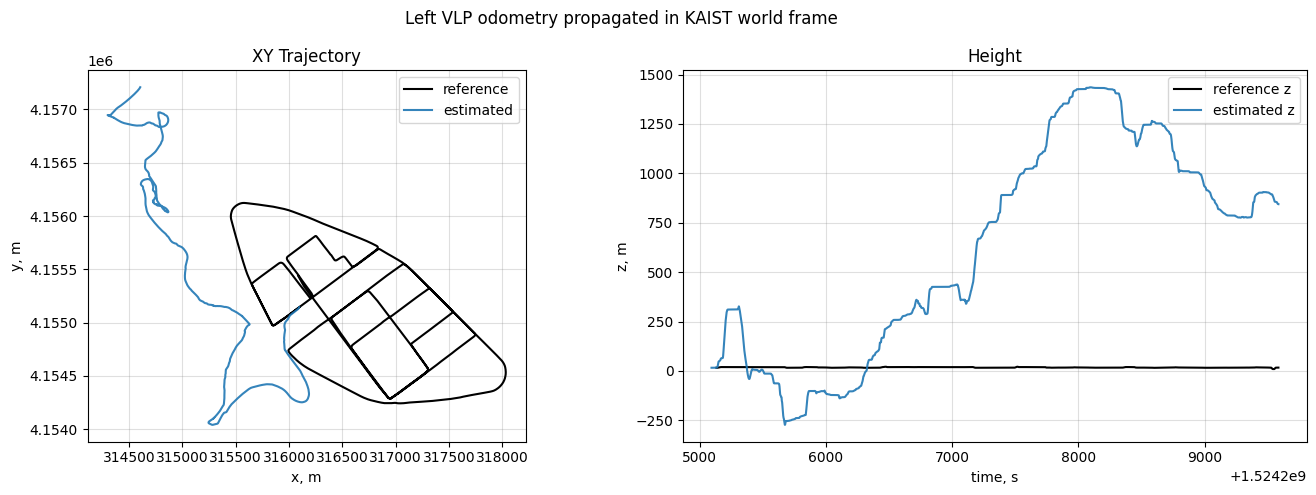

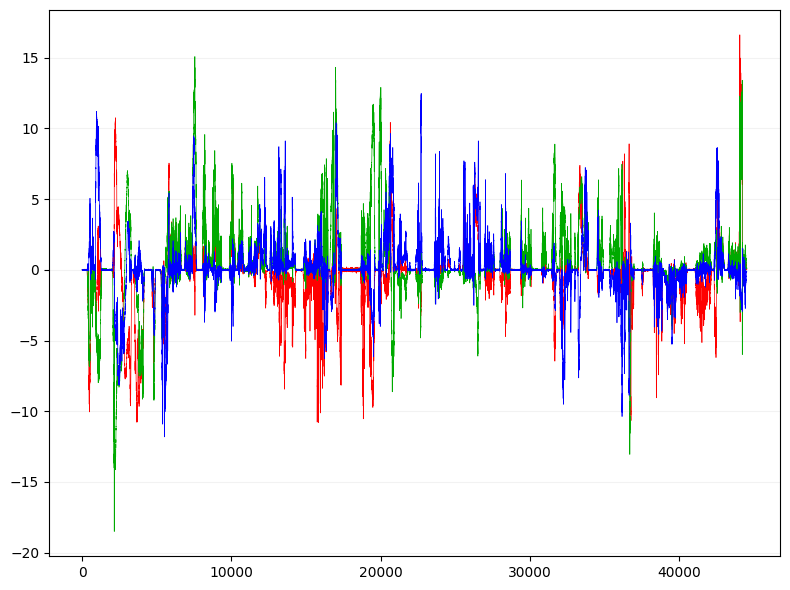

In [13]:
##################################################
# Compare LiDAR-derived body trajectory with KAIST reference
##################################################

reference_mask = (
    (true_timestamps >= lidar_timestamps[0])
    & (true_timestamps <= lidar_timestamps[-1])
)

fig, axes = plot_rolling_trajectory(
    lidar_timestamps,
    lidar_poses_world,
    reference_timestamps=true_timestamps[reference_mask],
    reference_poses=true_poses[reference_mask],
    title="Left VLP odometry propagated in KAIST world frame",
)

plt.show()

##################################################
# World-frame velocity of the LiDAR-derived BODY trajectory
##################################################

lidar_velocities_world = transform.se3_to_velocities(
    lidar_poses_world,
    lidar_timestamps,
    frame="world",
)

plot(lidar_velocities_world)

## 6. Create Pipeline Sensors, Streams, Variables, And RollingGraph

The physical IMU owns one shared extrinsic, one shared time offset, and one shared gyro-bias node. The gyro and accelerometer streams request the same IMU variables, while the LiDAR odometry stream requests the LiDAR variables.


In [16]:
imu = Sensor('imu_0', kind='imu')
lidar = Sensor('lidar_0', kind='lidar')
lidar_right = Sensor('lidar_1', kind='lidar')

gyro_stream = GyroStream(
    sensor=imu,
    timestamps=original_imu_timestamps,
    angular_velocity=original_gyrs,
    samples_per_factor=IMU_SAMPLES_PER_FACTOR,
    time_offset_margin=IMU_TIME_OFFSET_MARGIN,
    information=GYRO_INFORMATION,
)

if ACC_MODE == 'complex':
    accel_stream = ComplexAccelStream(
        sensor=imu,
        timestamps=original_imu_timestamps,
        acceleration=original_accs,
        angular_velocity=original_gyrs,
        samples_per_factor=IMU_SAMPLES_PER_FACTOR,
        time_offset_margin=IMU_TIME_OFFSET_MARGIN,
        gravity_world=GRAVITY_WORLD,
        information=ACCEL_INFORMATION,
    )
else:
    accel_stream = SimpleAccelStream(
        sensor=imu,
        timestamps=original_imu_timestamps,
        acceleration=original_accs,
        samples_per_factor=IMU_SAMPLES_PER_FACTOR,
        time_offset_margin=IMU_TIME_OFFSET_MARGIN,
        gravity_world=GRAVITY_WORLD,
        information=ACCEL_INFORMATION,
    )

lidar_stream = LidarOdometryStream(
    sensor=lidar,
    timestamps=lidar_timestamps,
    odometry_poses=lidar_poses,
    samples_per_factor=LIDAR_SAMPLES_PER_FACTOR,
    time_offset_margin=LIDAR_TIME_OFFSET_MARGIN,
    # information=LIDAR_INFORMATION_SCALE * np.diag(1.0 / lidar_noise**2),
    information = LIDAR_INFORMATION,
)
lidar_body_stream = LidarOdometryStream(
    sensor=lidar,
    timestamps=lidar_timestamps,
    odometry_poses=lidar_poses_body,
    samples_per_factor=LIDAR_SAMPLES_PER_FACTOR,
    time_offset_margin=LIDAR_TIME_OFFSET_MARGIN,
    # information=LIDAR_INFORMATION_SCALE * np.diag(1.0 / lidar_noise**2),
    information = LIDAR_INFORMATION,
)
lidar_right_stream = LidarOdometryStream(
    sensor=lidar_right,
    timestamps=lidar_right_timestamps,
    odometry_poses=lidar_right_poses,
    samples_per_factor=LIDAR_SAMPLES_PER_FACTOR,
    time_offset_margin=LIDAR_TIME_OFFSET_MARGIN,
    # information=LIDAR_INFORMATION_SCALE * np.diag(1.0 / lidar_noise**2),
    information = LIDAR_INFORMATION,
)

lidar_pose_streams = []
lidar_pose_left_stream = LidarPoseStream(
    sensor=lidar,
    timestamps=lidar_pose_timestamps_left,
    poses=lidar_poses_left,
    information=LIDAR_MAP_POSE_INFORMATION,
    factor_stride=LIDAR_MAP_POSE_FACTOR_STRIDE,
    stream_name='lidar_0.map_pose_left',
)
lidar_pose_streams.append(lidar_pose_left_stream)

lidar_pose_right_stream = None
if len(lidar_poses_right):
    lidar_pose_right_stream = LidarPoseStream(
        sensor=lidar_right,
        timestamps=lidar_pose_timestamps_right,
        poses=lidar_poses_right,
        information=LIDAR_MAP_POSE_INFORMATION,
        factor_stride=LIDAR_MAP_POSE_FACTOR_STRIDE,
        stream_name='lidar_1.map_pose_right',
    )
    lidar_pose_streams.append(lidar_pose_right_stream)

streams = [gyro_stream, accel_stream]
if USE_LIDAR_RELATIVE_ODOMETRY_FACTORS:
    streams.extend([lidar_stream, lidar_right_stream])
if USE_LIDAR_MAP_POSE_FACTORS:
    streams.extend(lidar_pose_streams)

imu_extrinsic_key = VariableKey('imu_0', VariableType.EXTRINSIC)
imu_tau_key = VariableKey('imu_0', VariableType.TIME_OFFSET)
imu_bias_key = VariableKey('imu_0', VariableType.GYRO_BIAS)
lidar_extrinsic_key = VariableKey('lidar_0', VariableType.EXTRINSIC)
lidar_tau_key = VariableKey('lidar_0', VariableType.TIME_OFFSET)
lidar_right_extrinsic_key = VariableKey('lidar_1', VariableType.EXTRINSIC)
lidar_right_tau_key = VariableKey('lidar_1', VariableType.TIME_OFFSET)

imu_prior_source = IMU_PRIOR_SOURCE
variable_configs = {
    imu_extrinsic_key: VariableConfig(
        initial_source='optimized',
        initial_value=T_B_I_INITIAL_FOR_DATASET,
        fixed=True,
        prior_source=imu_prior_source,
        prior_value=T_B_I_INITIAL_FOR_DATASET,
        prior_information=np.diag(T_B_I_PRIOR_INFORMATION_DIAG),
    ),
    imu_tau_key: VariableConfig(
        initial_source='optimized',
        initial_value=TAU_I_ESTIMATE_INITIAL,
        fixed=False,
        prior_source=imu_prior_source,
        prior_value=TAU_I_ESTIMATE_INITIAL,
        prior_information=TAU_I_PRIOR_INFORMATION,
    ),
    # imu_tau_key: VariableConfig(
    #     initial_source="constant",
    #     initial_value=TAU_I_REFERENCE,
    #     fixed=True,
    # ),
    imu_bias_key: VariableConfig(
        initial_source='optimized',
        initial_value=BIAS_ESTIMATE_INITIAL,
        fixed=False,
        prior_source='constant',
        prior_value=BIAS_ESTIMATE_INITIAL,
        prior_information=BIAS_PRIOR_INFORMATION,
    ),
    lidar_extrinsic_key: VariableConfig(
        initial_source='constant',
        initial_value=T_B_LL_INITIAL,
        fixed=True,
        prior_source="optimized",
        prior_value=T_B_LL_INITIAL,
        prior_information=np.diag(T_B_I_PRIOR_INFORMATION_DIAG),
    ),
    lidar_tau_key: VariableConfig(
        initial_source='constant',
        initial_value=TAU_L_ESTIMATE_INITIAL,
        fixed=True,
    ),
    lidar_right_extrinsic_key: VariableConfig(
        initial_source='constant',
        initial_value=T_B_RL_INITIAL,
        fixed=True,
        prior_source="optimized",
        prior_value=T_B_RL_INITIAL,
        prior_information=np.diag(T_B_I_PRIOR_INFORMATION_DIAG),
    ),
    lidar_right_tau_key: VariableConfig(
        initial_source='constant',
        initial_value=TAU_L_ESTIMATE_INITIAL,
        fixed=True,
    ),
}

rolling_graph = RollingGraph(
    streams=streams,
    sensors=[imu, lidar, lidar_right],
    variable_configs=variable_configs,
    solver_config=SolverConfig(
        method=FACTOR_GRAPH_METHOD,
        scheduler=SOLVER_SCHEDULER,
        solver_verbose=False,
    ),
    trajectory_config=TrajectoryConfig(
        anchor_first_pose=True,
        anchor_first_pose_each_window=True,
        anchor_last_pose=False,
        anchor_all_poses=False,
        use_imu_gyr=False,
    ),
)

pd.DataFrame([
    {'stream': stream.stream_name, 'type': stream.stream_type, 'sensor': stream.sensor.sensor_id, 'requirements': [req.key.label for req in stream.required_variables()]}
    for stream in streams
])


,stream,type,sensor,requirements
0,imu_0.gyro,gyro,imu_0,"[imu_0:extrinsic, imu_0:time_offset, imu_0:gyr..."
1,imu_0.accel,simple_accel,imu_0,"[imu_0:extrinsic, imu_0:time_offset]"
2,lidar_0.odometry,lidar_odometry,lidar_0,"[lidar_0:extrinsic, lidar_0:time_offset]"
3,lidar_1.odometry,lidar_odometry,lidar_1,"[lidar_1:extrinsic, lidar_1:time_offset]"


## 7. Plot Measurements From The Pipeline Stream Objects

These plots read directly from the `GyroStream`, `ComplexAccelStream`/`SimpleAccelStream`, and `LidarOdometryStream` objects that will produce graph factors.


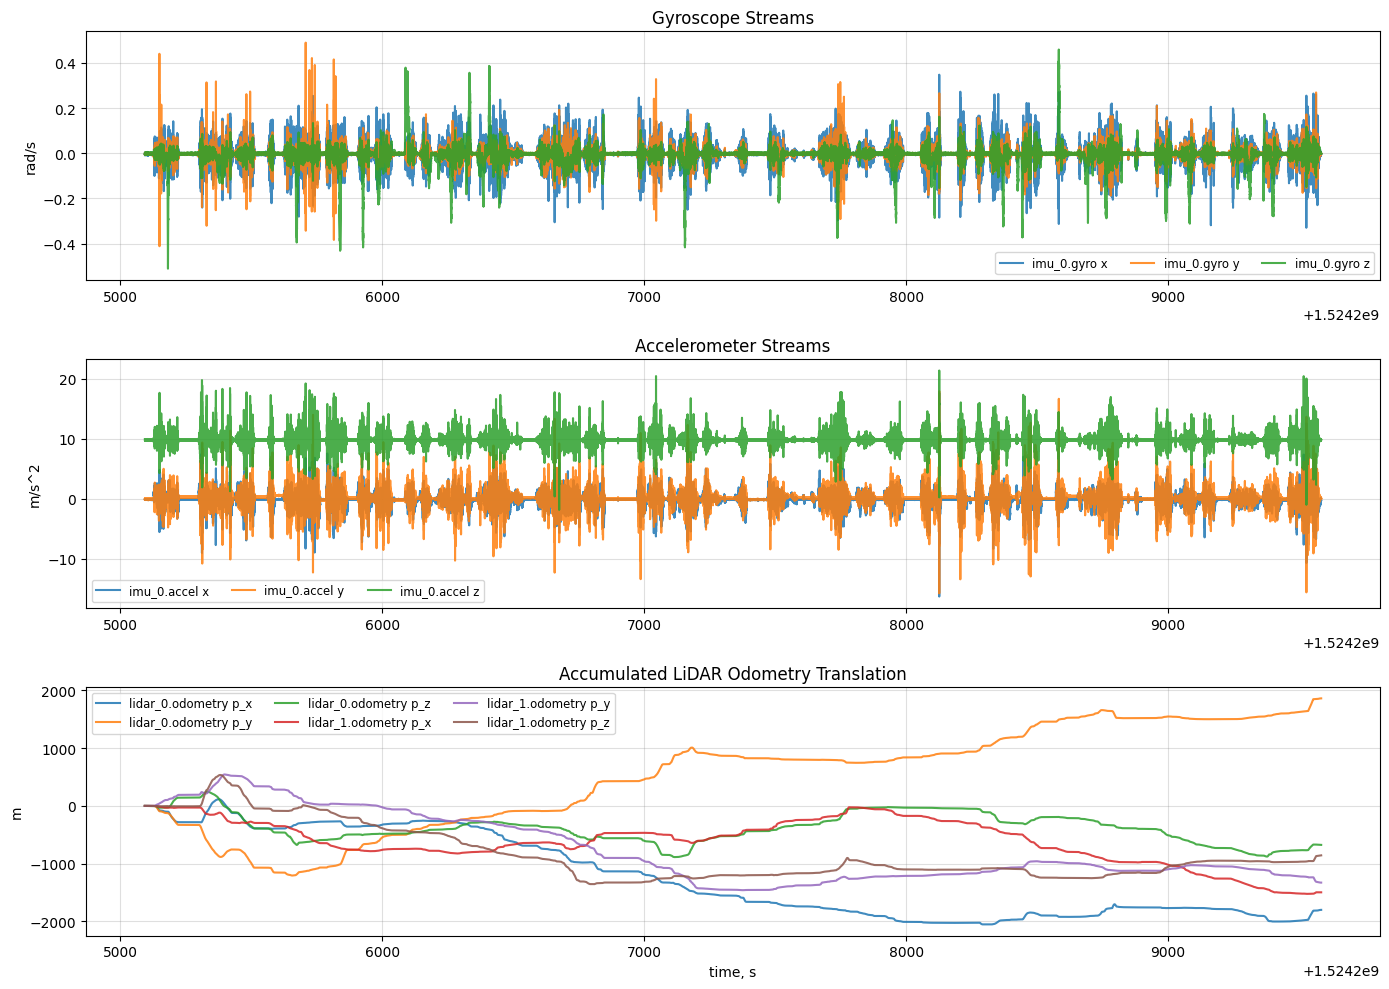

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


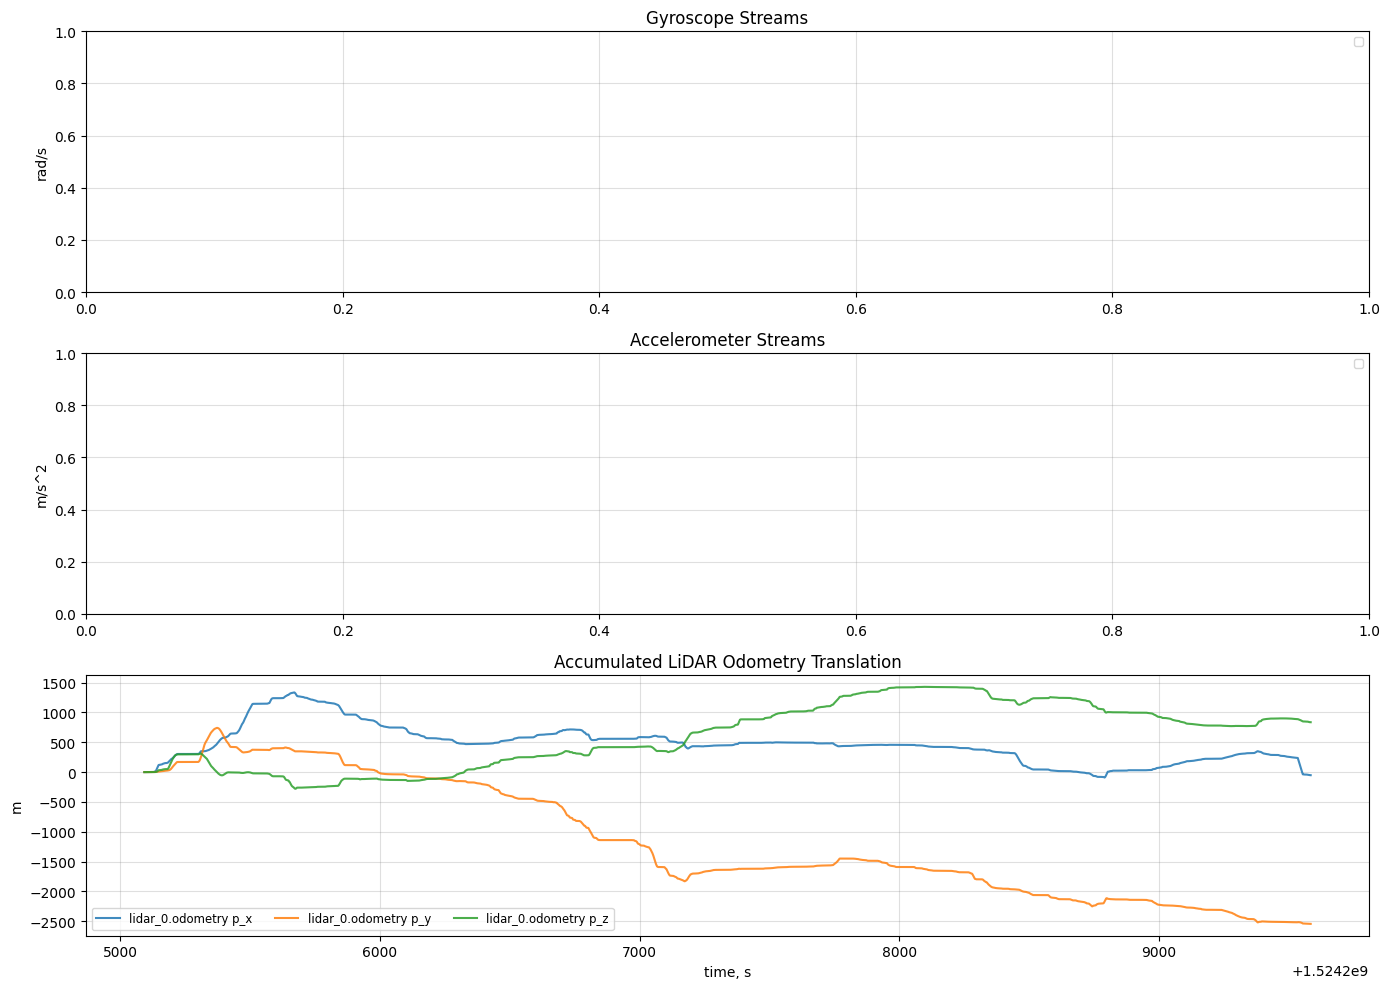

In [17]:
fig, axes = plot_stream_measurements(streams)
if SAVE_FIGURES:
    fig.savefig(OUT / 'pipeline_stream_measurements.png', dpi=160)
plt.show()
plt.close(fig)
fig, axes = plot_stream_measurements([lidar_body_stream])
plt.show()
plt.close(fig)


## 8. Initialize The Trajectory

The initialization path reuses the existing `data_processing._initialize_trajectory_poses` helper, just as notebook 15 did. The new pipeline will also reuse this helper internally whenever it needs to propagate missing poses.


initial-pose timestamp mismatch [s]: 38.57484817504883


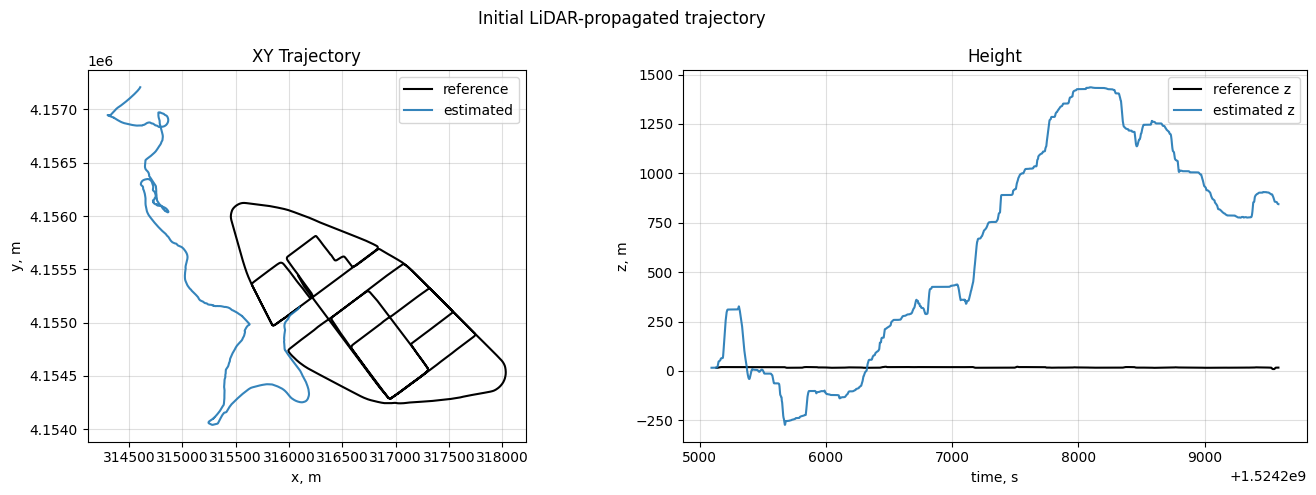

In [18]:
pose_slice = slice(5, -5)

if USE_LIDAR_MAP_POSE_FACTORS:
    pose_time_start = lidar_pose_timestamps_left[0]
    pose_time_end = lidar_pose_timestamps_left[-1]
    if len(lidar_pose_timestamps_right):
        pose_time_start = max(pose_time_start, lidar_pose_timestamps_right[0])
        pose_time_end = min(pose_time_end, lidar_pose_timestamps_right[-1])
    pose_time_start = max(pose_time_start, true_timestamps[0])
    pose_time_end = min(pose_time_end, true_timestamps[-1])
    pose_mask = (lidar_pose_timestamps_left >= pose_time_start) & (lidar_pose_timestamps_left <= pose_time_end)
    window_pose_timestamps = lidar_pose_timestamps_left[pose_mask]
    init_lidar_poses = lidar_poses_left[pose_mask].copy()
    if len(window_pose_timestamps) == 0:
        raise ValueError('No absolute LiDAR pose observations overlap the reference trajectory support.')
    first_lidar_true_index = np.argmin(np.abs(true_timestamps - window_pose_timestamps[0]))
    print('initial-pose timestamp mismatch [s]:', true_timestamps[first_lidar_true_index] - window_pose_timestamps[0])
    init_title = 'Initial trajectory from left LiDAR scan-to-map pose observations'
else:
    # window_pose_timestamps = pose_timestamps[pose_slice]
    window_pose_timestamps = lidar_timestamps
    first_lidar_true_index = np.argmin(np.abs(true_timestamps - window_pose_timestamps[0]))
    first_lidar_true_pose = true_poses[first_lidar_true_index].copy()
    print('initial-pose timestamp mismatch [s]:', true_timestamps[first_lidar_true_index] - window_pose_timestamps[0])
    init_lidar_poses = data_processing._initialize_trajectory_poses(
        pose_timestamps=window_pose_timestamps,
        states=[first_lidar_true_pose],
        first_pose=first_lidar_true_pose,
        imu_timestamps=original_imu_timestamps,
        angular_velocity_imu=original_gyrs,
        T_B_I_initial=T_B_I_INITIAL_FOR_DATASET,
        bias_initial=BIAS_ESTIMATE_INITIAL,
        tau_I_initial=TAU_I_ESTIMATE_INITIAL,
        lidar_timestamps=lidar_timestamps,
        lidar_odometry_poses=lidar_poses,
        T_B_L_initial=T_B_LL_INITIAL,
        tau_L_initial=TAU_L_ESTIMATE_INITIAL,
    )
    init_title = 'Initial LiDAR-propagated trajectory'

reference_mask = (true_timestamps >= window_pose_timestamps[0]) & (true_timestamps <= window_pose_timestamps[-1])
fig, axes = plot_rolling_trajectory(
    window_pose_timestamps,
    init_lidar_poses,
    reference_timestamps=true_timestamps[reference_mask],
    reference_poses=true_poses[reference_mask],
    title=init_title,
)
if SAVE_FIGURES:
    fig.savefig(OUT / 'initial_lidar_trajectory.png', dpi=160)
plt.show()
plt.close(fig)

## 9. Solve The Rolling Graph

`RollingGraph` now owns orchestration only: it creates trajectory nodes, resolves shared calibration variables, adds priors, asks each stream to add factors, solves, and updates `RollingState`.


In [19]:
results = rolling_graph.generate_filter_iterative(
    window_size=WINDOW_SIZE * 100,
    step_size=WINDOW_SIZE * 100 / 2,
    pose_timestamps=window_pose_timestamps,
    states=init_lidar_poses,
    first_pose=init_lidar_poses[0],
    clear_previous=True,
    verbose=0,
)

estimated_timestamps, estimated_poses = rolling_graph.rolling_state.rolling_trajectory
print(f'accelerometer mode: {ACC_MODE}')
print(f'solved windows: {len(results)}')
print(f'stitched estimated poses: {estimated_poses.shape}')
if results:
    print_rolling_result_summary(results[-1])


accelerometer mode: simple
solved windows: 17
stitched estimated poses: (44435, 4, 4)
window 16: [1524209098.031, 1524209579.795]
poses: 4777
chi2: 4.574274e+05 -> 1.885419e+05
factor counts: {'gyro_calib_prop': 4776, 'accel_gravity_calib': 4777, 'lidar_calib_odometry': 9552, 'gyro_bias_prior': 1, 'time_offset_prior': 1}
imu_0:extrinsic Ln: [-0.    0.   -0.    0.07  0.   -1.7 ]
imu_0:gyro_bias: [ 1.35599648e-05 -9.37324416e-07  6.36446658e-06]
imu_0:time_offset: 2.067742900739724
lidar_0:extrinsic Ln: [-0.90803571  0.39962948  2.22131152 -0.54393308 -0.02053702  1.94245679]
lidar_0:time_offset: 0.0
lidar_1:extrinsic Ln: [ 0.90791977  0.37832564 -2.22225243 -0.50817814  0.01112482  1.96196077]
lidar_1:time_offset: 0.0


## 10. Inspect Rolling Results And Constructed Metadata

The metadata is intentionally visualization-neutral: it describes nodes, variables, streams, factors, and priors without depending on graph drawing libraries.


In [20]:
display(result_table(results).tail())

metadata = rolling_graph.metadata
print('trajectory nodes in last graph:', len(metadata.trajectory_nodes))
print('calibration variables in last graph:', len(metadata.calibration_variables))
print('factors in last graph:', len(metadata.factors))
print('priors in last graph:', len(metadata.priors))
print('last graph factor counts:', metadata.factor_counts)

pd.DataFrame([
    {
        'key': variable.key.label,
        'node_id': variable.node_id,
        'fixed': variable.fixed,
        'initial_source': variable.initial_source.value,
    }
    for variable in metadata.calibration_variables
])


,window,start,end,chi2_before,chi2_after,factors,imu_0:time_offset,lidar_0:time_offset,lidar_1:time_offset
12,12,1.524208e+09,1.524209e+09,277538.371670,12912.471846,19827,2.051519,0.0,0.0
13,13,1.524208e+09,1.524209e+09,81628.093729,29911.959957,19827,2.051894,0.0,0.0
14,14,1.524209e+09,1.524209e+09,65821.229410,55993.361047,19827,2.064793,0.0,0.0
15,15,1.524209e+09,1.524209e+09,138780.978200,126028.904421,19827,2.064692,0.0,0.0
16,16,1.524209e+09,1.524210e+09,457427.387759,188541.860560,19107,2.067743,0.0,0.0


trajectory nodes in last graph: 0
calibration variables in last graph: 0
factors in last graph: 0
priors in last graph: 0
last graph factor counts: {}


""


## 11. Plot The Resulting Trajectory

The stitched rolling output is plotted against the properly rotated New College ground-truth trajectory and the LiDAR-propagated initialization.


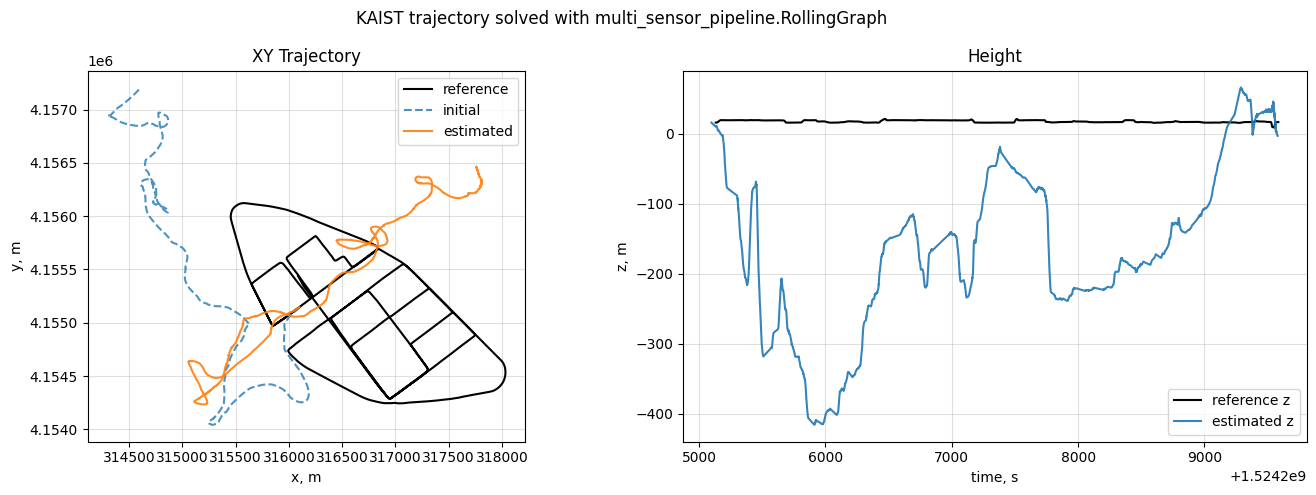

In [21]:
result_reference_mask = (
    (true_timestamps >= estimated_timestamps[0])
    & (true_timestamps <= estimated_timestamps[-1])
)

fig, axes = plot_rolling_trajectory(
    estimated_timestamps,
    estimated_poses,
    reference_timestamps=true_timestamps[result_reference_mask],
    reference_poses=true_poses[result_reference_mask],
    initial_poses=init_lidar_poses,
    title='KAIST trajectory solved with multi_sensor_pipeline.RollingGraph',
)
if SAVE_FIGURES:
    fig.savefig(OUT / 'rolling_graph_trajectory_result.png', dpi=160)
plt.show()
plt.close(fig)


## 12. Plot Calibration Variables Over Time

The IMU extrinsic, IMU time offset, IMU gyro bias, fixed LiDAR extrinsic, and fixed LiDAR time offset all come from the new `WindowResult.calibration_values` dictionary keyed by `VariableKey`.


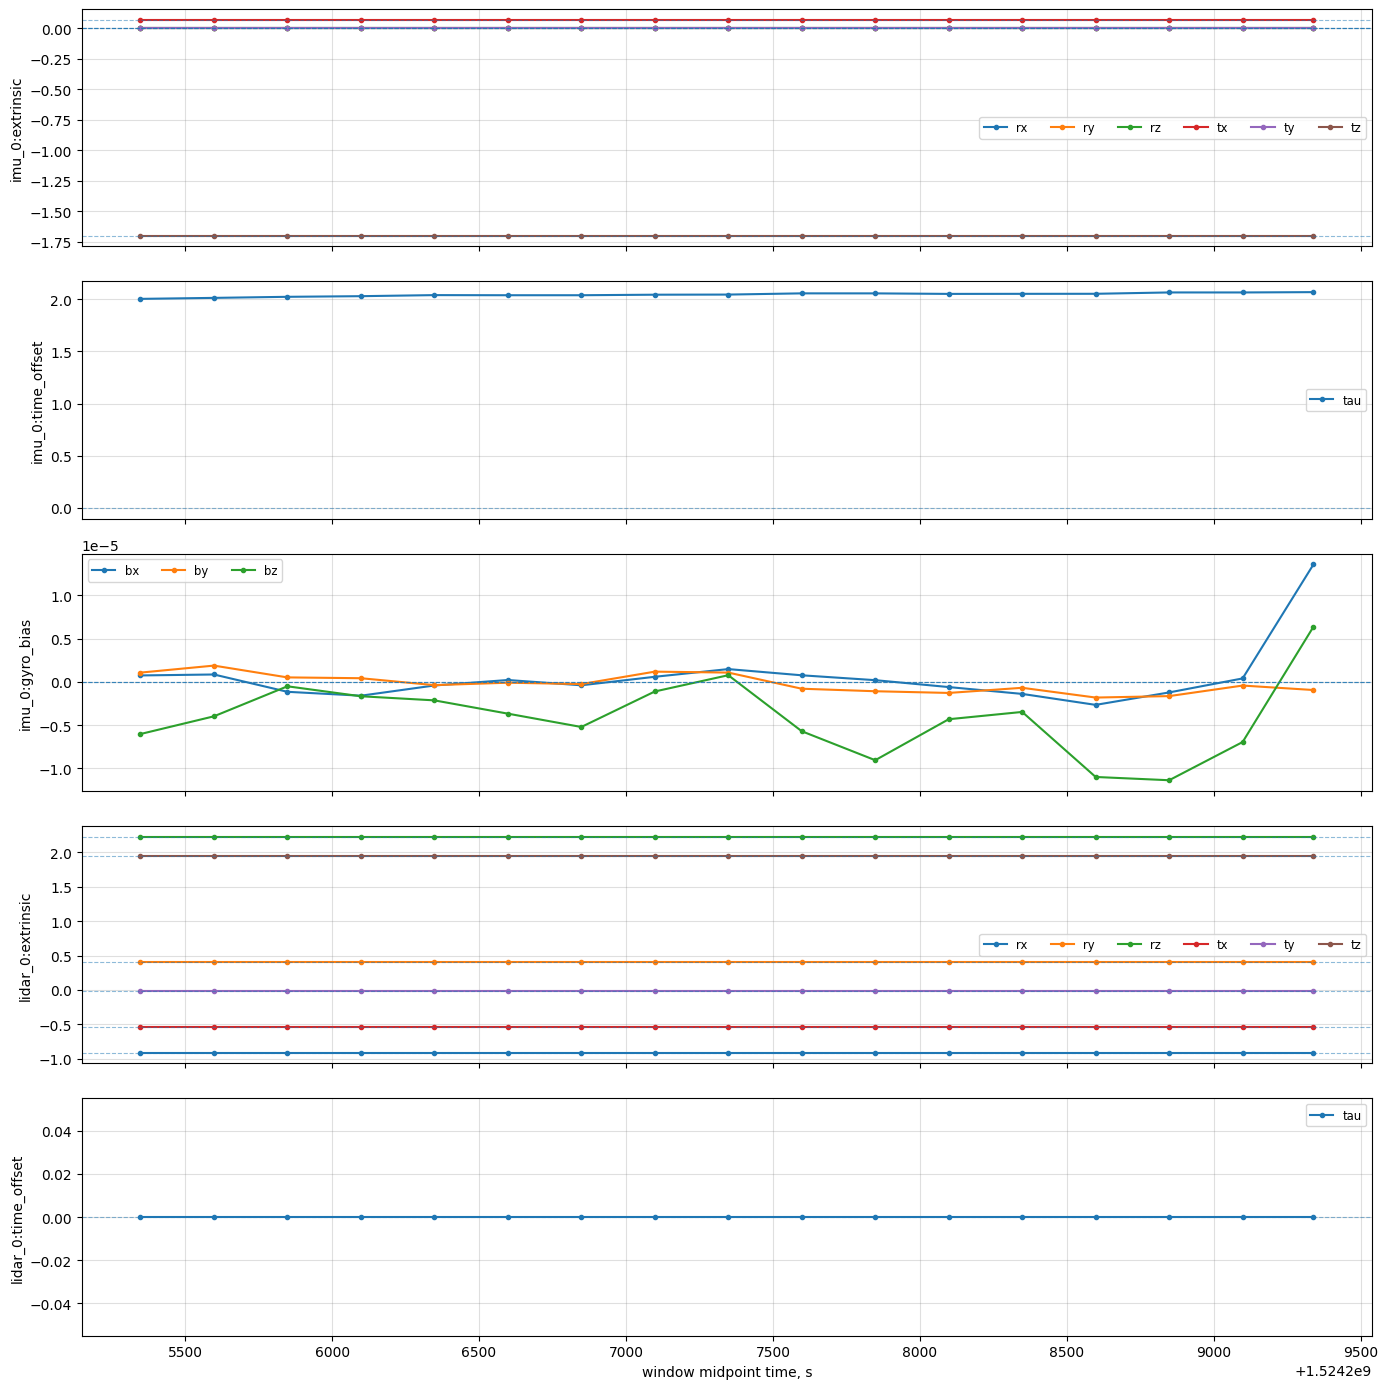

In [22]:
calibration_keys = [
    imu_extrinsic_key,
    imu_tau_key,
    imu_bias_key,
    lidar_extrinsic_key,
    lidar_tau_key,
]
reference_values = {
    imu_extrinsic_key: T_B_I_REFERENCE,
    imu_tau_key: TAU_I_REFERENCE,
    imu_bias_key: BIAS_REFERENCE,
    lidar_extrinsic_key: T_B_L_REFERENCE,
    lidar_tau_key: TAU_L_REFERENCE,
}

fig, axes = plot_calibration_estimates(results, calibration_keys, reference_values=reference_values)
if SAVE_FIGURES:
    fig.savefig(OUT / 'rolling_graph_calibration_variables.png', dpi=160)
plt.show()
plt.close(fig)


## 13. Notes

- Gyro and accelerometer streams both reference `imu_0`, so they share `imu_0:extrinsic` and `imu_0:time_offset` nodes.
- Initial values and priors are configured separately through `VariableConfig`.
- `IMU_PRIOR_SOURCE = 'optimized'` makes the first IMU soft prior fall back to the configured `prior_value`, then uses the previous rolling-window calibration estimate as the prior target in later windows. Set it to `'numerical'` to use cached numerical calibration as the prior source instead.
- The graph metadata is ready for a future visualizer, but this notebook intentionally does not implement graph visualization.


# 14. Diagnostics

In [23]:
##################################################
# Short reference-initialized diagnostic interval
##################################################

reference_window_poses = true_poses[pose_slice]
reference_true_timestamps = true_timestamps[pose_slice]

diagnostic_start = max(
    true_timestamps[0],
    lidar_timestamps[0] + LIDAR_TIME_OFFSET_MARGIN,
)

diagnostic_end = diagnostic_start + 50.0

diagnostic_mask = (
    (reference_true_timestamps >= diagnostic_start)
    & (reference_true_timestamps <= diagnostic_end)
)

diagnostic_timestamps = reference_true_timestamps[diagnostic_mask]
diagnostic_reference_poses = reference_window_poses[diagnostic_mask]

In [24]:
##################################################
# LiDAR-only graph with all calibration fixed
##################################################

diagnostic_graph = RollingGraph(
    streams=[
        lidar_stream,
    ],
    sensors=[
        lidar,
    ],
    variable_configs={
        lidar_extrinsic_key: VariableConfig(
            initial_source="constant",
            initial_value=T_B_LL_INITIAL,
            fixed=True,
        ),
        lidar_tau_key: VariableConfig(
            initial_source="constant",
            initial_value=0.0,
            fixed=True,
        ),
    },
    solver_config=SolverConfig(
        method="LM",
        scheduler=[
            (1e-5, 20),
        ],
        solver_verbose=False,
    ),
    trajectory_config=TrajectoryConfig(
        anchor_first_pose=True,
        anchor_first_pose_each_window=False,
        anchor_last_pose=False,
        anchor_all_poses=False,
        use_imu_gyr=False,
    ),
)

diagnostic_result = diagnostic_graph.generate_filter(
    pose_timestamps=diagnostic_timestamps,
    states=diagnostic_reference_poses,
    first_pose=diagnostic_reference_poses[0],
)

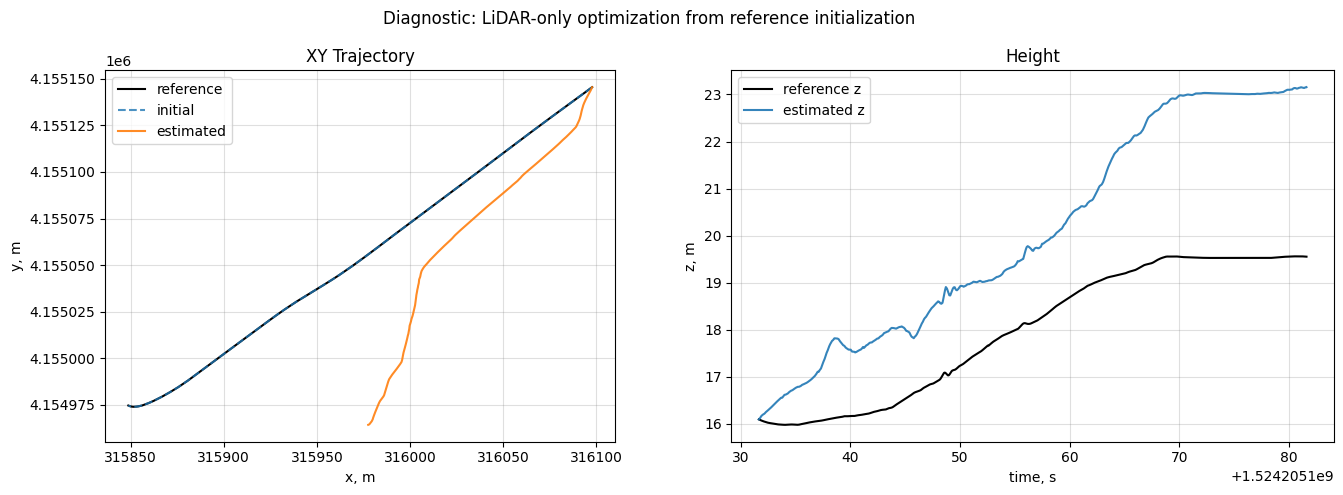

In [25]:
fig, axes = plot_rolling_trajectory(
    diagnostic_result.pose_timestamps,
    diagnostic_result.trajectory_poses,
    reference_timestamps=diagnostic_timestamps,
    reference_poses=diagnostic_reference_poses,
    initial_poses=diagnostic_reference_poses,
    title="Diagnostic: LiDAR-only optimization from reference initialization",
)

plt.show()

In [26]:
##################################################
# Diagnose reference / sensor timestamp support
##################################################

gt_dt = np.diff(true_timestamps)
lidar_dt = np.diff(lidar_timestamps)
imu_dt = np.diff(original_imu_timestamps)

print("GT:")
print("  start:", true_timestamps[0])
print("  end:", true_timestamps[-1])
print("  duration:", true_timestamps[-1] - true_timestamps[0])
print("  median dt:", np.median(gt_dt))
print("  max dt:", np.max(gt_dt))

print()

print("LiDAR:")
print("  start:", lidar_timestamps[0])
print("  end:", lidar_timestamps[-1])
print("  duration:", lidar_timestamps[-1] - lidar_timestamps[0])
print("  median dt:", np.median(lidar_dt))
print("  max dt:", np.max(lidar_dt))

print()

print("IMU:")
print("  start:", original_imu_timestamps[0])
print("  end:", original_imu_timestamps[-1])
print("  duration:", original_imu_timestamps[-1] - original_imu_timestamps[0])
print("  median dt:", np.median(imu_dt))
print("  max dt:", np.max(imu_dt))

##################################################
# Locate suspicious gaps in the reference trajectory
##################################################

gt_gap_threshold = max(
    0.1,
    5.0 * np.median(gt_dt),
)

gt_gap_indices = np.flatnonzero(
    gt_dt > gt_gap_threshold
)

print()
print(
    "GT gaps larger than",
    gt_gap_threshold,
    "s:",
    len(gt_gap_indices),
)

largest_gap_indices = np.argsort(gt_dt)[-20:][::-1]

for index in largest_gap_indices:
    print(
        index,
        "dt =",
        gt_dt[index],
        "from",
        true_timestamps[index],
        "to",
        true_timestamps[index + 1],
    )

GT:
  start: 1524205131.6004922
  end: 1524209584.84052
  duration: 4453.240027666092
  median dt: 0.010200023651123047
  max dt: 79.78091430664062

LiDAR:
  start: 1524205093.025644
  end: 1524209584.807602
  duration: 4491.781957864761
  median dt: 0.10085701942443848
  max dt: 0.10354137420654297

IMU:
  start: 1524205093.0313678
  end: 1524209584.8013678
  duration: 4491.7699999809265
  median dt: 0.009999990463256836
  max dt: 0.010000228881835938

GT gaps larger than 0.1 s: 172
165002 dt = 79.78091430664062 from 1524207391.7112527 to 1524207471.492167
8553 dt = 75.75332069396973 from 1524205222.6105194 to 1524205298.36384
202493 dt = 65.8346016407013 from 1524207990.177681 to 1524208056.0122826
209906 dt = 59.6301531791687 from 1524208133.2421277 to 1524208192.8722808
234293 dt = 52.36999750137329 from 1524208518.4824035 to 1524208570.852401
256144 dt = 51.81290006637573 from 1524208898.0414243 to 1524208949.8543243
131728 dt = 51.28004765510559 from 1524206848.571483 to 15242068

LiDAR - IMU mean rotation residual [deg]: [-0.02541856 -0.02023476  0.05983745]
LiDAR - IMU median rotation residual [deg]: [0.01214978 0.00747602 0.01094841]
LiDAR - IMU RMS residual [deg]: [0.17197349 0.15356214 0.30853866]


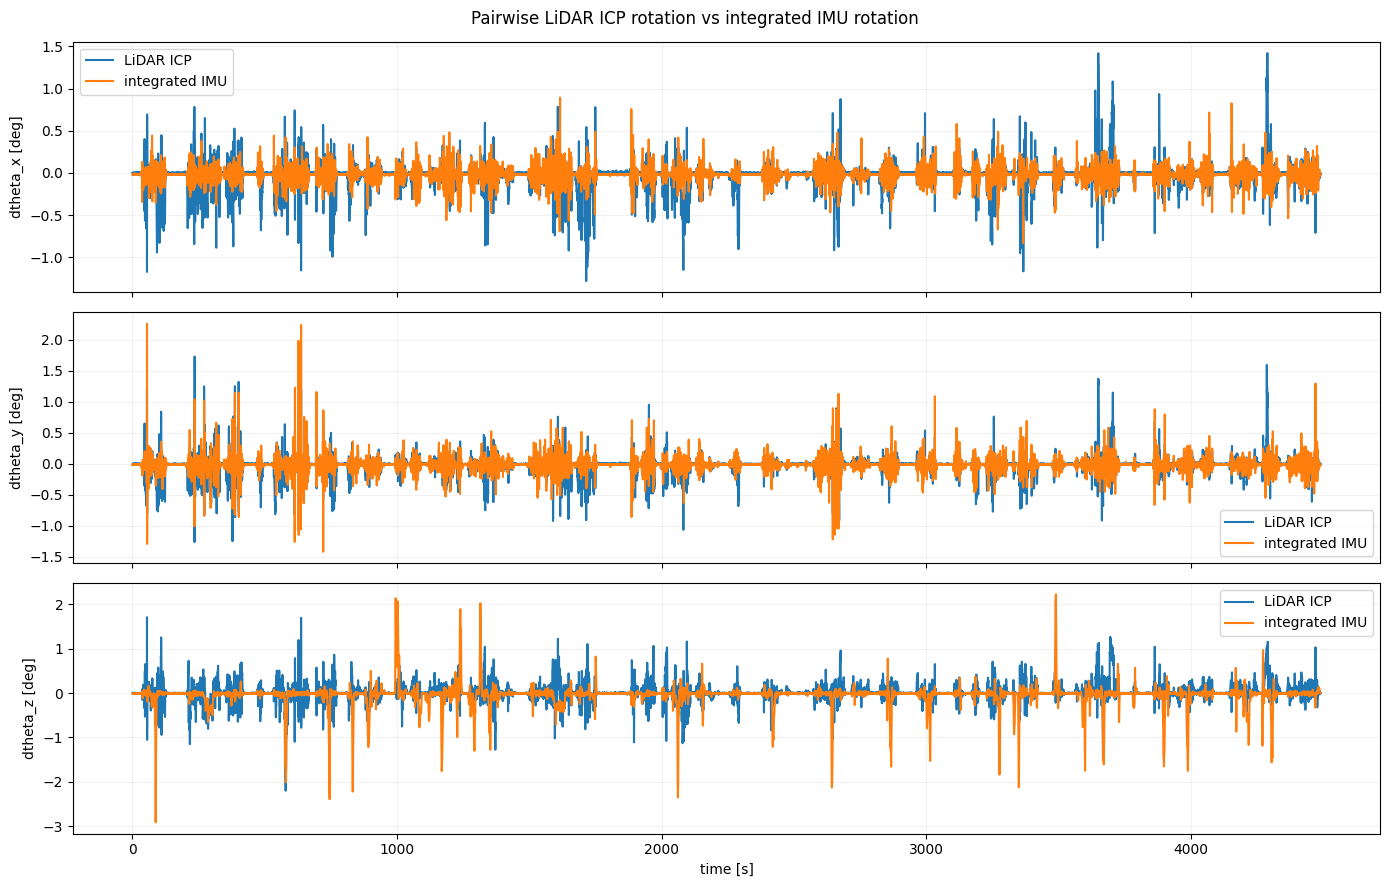

In [27]:
##################################################
# Compare pairwise LiDAR rotation against integrated IMU rotation
##################################################

from scipy.spatial.transform import Rotation


def integrate_gyro_rotation(
    time_start,
    time_end,
    imu_timestamps,
    gyroscope,
    bias=None,
):
    """
    Integrate gyroscope measurements over one LiDAR scan interval.

    The returned rotation is the relative IMU-frame rotation from the
    beginning of the interval to the end.
    """

    imu_timestamps = np.asarray(
        imu_timestamps,
        dtype=float,
    )

    gyroscope = np.asarray(
        gyroscope,
        dtype=float,
    )

    if bias is None:
        bias = np.zeros(3, dtype=float)
    else:
        bias = np.asarray(
            bias,
            dtype=float,
        )

    ##################################################
    # Collect internal IMU samples and interpolate both interval boundaries
    ##################################################

    internal_mask = (
        (imu_timestamps > time_start)
        & (imu_timestamps < time_end)
    )

    internal_times = imu_timestamps[
        internal_mask
    ]

    interval_times = np.concatenate((
        [time_start],
        internal_times,
        [time_end],
    ))

    interval_gyr = np.empty(
        (len(interval_times), 3),
        dtype=float,
    )

    for axis in range(3):
        interval_gyr[:, axis] = np.interp(
            interval_times,
            imu_timestamps,
            gyroscope[:, axis],
        )

    interval_gyr -= bias

    ##################################################
    # Midpoint integration on SO(3)
    ##################################################

    R_interval = np.eye(3)

    for sample_index, dt in enumerate(
        np.diff(interval_times)
    ):
        omega_mid = 0.5 * (
            interval_gyr[sample_index]
            + interval_gyr[sample_index + 1]
        )

        R_interval = (
            R_interval
            @ Rotation.from_rotvec(
                omega_mid * dt
            ).as_matrix()
        )

    return R_interval


##################################################
# Compare a manageable subset first
##################################################

comparison_indices = np.arange(
    len(lidar_relative_poses_body),
    step=5,
)

valid_time_mask = (
    (lidar_timestamps[comparison_indices] >= original_imu_timestamps[0])
    & (
        lidar_timestamps[comparison_indices + 1]
        <= original_imu_timestamps[-1]
    )
)

comparison_indices = comparison_indices[
    valid_time_mask
]

R_B_I = T_B_I_INITIAL_FOR_DATASET[
    :3,
    :3,
]

R_I_B = R_B_I.T

rotation_residuals = []
lidar_rotation_vectors = []
imu_rotation_vectors = []

for interval_index in comparison_indices:
    time_start = lidar_timestamps[
        interval_index
    ]

    time_end = lidar_timestamps[
        interval_index + 1
    ]

    ##################################################
    # IMU relative rotation, converted into body coordinates
    ##################################################

    R_I0_I1 = integrate_gyro_rotation(
        time_start,
        time_end,
        original_imu_timestamps,
        original_gyrs,
        bias=np.zeros(3),
    )

    R_B0_B1_imu = (
        R_B_I
        @ R_I0_I1
        @ R_I_B
    )

    ##################################################
    # LiDAR relative rotation, already converted to body coordinates
    ##################################################

    R_B0_B1_lidar = lidar_relative_poses_body[
        interval_index,
        :3,
        :3,
    ]

    ##################################################
    # Residual: LiDAR rotation relative to IMU rotation
    ##################################################

    R_error = (
        R_B0_B1_imu.T
        @ R_B0_B1_lidar
    )

    rotation_residuals.append(
        Rotation.from_matrix(
            R_error
        ).as_rotvec()
    )

    lidar_rotation_vectors.append(
        Rotation.from_matrix(
            R_B0_B1_lidar
        ).as_rotvec()
    )

    imu_rotation_vectors.append(
        Rotation.from_matrix(
            R_B0_B1_imu
        ).as_rotvec()
    )


rotation_residuals = np.asarray(
    rotation_residuals
)

lidar_rotation_vectors = np.asarray(
    lidar_rotation_vectors
)

imu_rotation_vectors = np.asarray(
    imu_rotation_vectors
)

##################################################
# Report systematic LiDAR-vs-IMU rotational disagreement
##################################################

print(
    "LiDAR - IMU mean rotation residual [deg]:",
    np.rad2deg(
        np.mean(
            rotation_residuals,
            axis=0,
        )
    ),
)

print(
    "LiDAR - IMU median rotation residual [deg]:",
    np.rad2deg(
        np.median(
            rotation_residuals,
            axis=0,
        )
    ),
)

print(
    "LiDAR - IMU RMS residual [deg]:",
    np.rad2deg(
        np.sqrt(
            np.mean(
                rotation_residuals**2,
                axis=0,
            )
        )
    ),
)

##################################################
# Plot corresponding body-frame incremental rotations
##################################################

fig, axes = plt.subplots(
    3,
    1,
    figsize=(14, 9),
    sharex=True,
)

comparison_times = lidar_timestamps[
    comparison_indices
]

comparison_times = (
    comparison_times
    - comparison_times[0]
)

axis_names = ("x", "y", "z")

for axis_index, axis_name in enumerate(
    axis_names
):
    axes[axis_index].plot(
        comparison_times,
        np.rad2deg(
            lidar_rotation_vectors[
                :,
                axis_index,
            ]
        ),
        label="LiDAR ICP",
    )

    axes[axis_index].plot(
        comparison_times,
        np.rad2deg(
            imu_rotation_vectors[
                :,
                axis_index,
            ]
        ),
        label="integrated IMU",
    )

    axes[axis_index].set_ylabel(
        f"dtheta_{axis_name} [deg]"
    )

    axes[axis_index].grid(True)
    axes[axis_index].legend()

axes[-1].set_xlabel(
    "time [s]"
)

fig.suptitle(
    "Pairwise LiDAR ICP rotation vs integrated IMU rotation"
)

fig.tight_layout()
plt.show()